You're working as a sports journalist at a major online sports media company, specializing in soccer analysis and reporting. You've been watching both men's and women's international soccer matches for a number of years, and your gut instinct tells you that more goals are scored in women's international football matches than men's. This would make an interesting investigative article that your subscribers are bound to love, but you'll need to perform a valid statistical hypothesis test to be sure!

While scoping this project, you acknowledge that the sport has changed a lot over the years, and performances likely vary a lot depending on the tournament, so you decide to limit the data used in the analysis to only official `FIFA World Cup` matches (not including qualifiers) since `2002-01-01`.

You create two datasets containing the results of every official men's and women's international football match since the 19th century, which you scraped from a reliable online source. This data is stored in two CSV files: `women_results.csv` and `men_results.csv`.

The question you are trying to determine the answer to is:

> Are more goals scored in women's international soccer matches than men's?

You assume a **10% significance level**, and use the following null and alternative hypotheses:

$H_0$ : The mean number of goals scored in women's international soccer matches is the same as men's.

$H_A$ : The mean number of goals scored in women's international soccer matches is greater than men's.

## Project Instructions:
Perform an appropriate hypothesis test to determine the p-value, and hence result, of whether to reject or fail to reject the null hypothesis that the mean number of goals scored in women's international soccer matches is the same as men's. Use a 10% significance level.

For this analysis, you'll use Official FIFA World Cup matches since 2002-01-01, and you'll also assume that each match is fully independent, i.e., team form is ignored.

The p-value and the result of the test must be stored in a dictionary called result_dict in the form:

result_dict = {"p_val": p_val, "result": result}

where p_val is the p-value and result is either the string "fail to reject" or "reject", depending on the result of the test.

## How to approach the project:
1. **Exploratory data analysis:** Load the data from men_results.csv and women_results.csv to understand its contents.

2. **Filtering the data:** Filter the data to only include official FIFA World Cup matches that took place after 2002-01-01.

3. **Choosing the correct hypothesis test:** Use EDA to determine the appropriate hypothesis test for this dataset and scenario.

4. **Performing the hypothesis test:** Once you've decided on the correct hypothesis test to perform, carry out the test to return the p-value.

5. **Interpreting the result of the hypothesis test:** Interpret the p-value to determine if there is statistical significance between the two groups, assuming a 10% significance level.

In [5]:
# Start your code here!
import pandas as pd
import matplotlib.pyplot as plt
import pingouin
from scipy.stats import mannwhitneyu

In [6]:
men = pd.read_csv("E:\\Data Science Course\\Projects\\10. Hypothesis Testing with Men's and Women's Soccer Matches\\men_results.csv")
women = pd.read_csv("E:\\Data Science Course\\Projects\\10. Hypothesis Testing with Men's and Women's Soccer Matches\\women_results.csv")

In [7]:
men.head()

,date,home_team,away_team,home_score,away_score,tournament
0,1872-11-30,Scotland,England,0,0,Friendly
1,1873-03-08,England,Scotland,4,2,Friendly
2,1874-03-07,Scotland,England,2,1,Friendly
3,1875-03-06,England,Scotland,2,2,Friendly
4,1876-03-04,Scotland,England,3,0,Friendly


In [8]:
women.head()

,date,home_team,away_team,home_score,away_score,tournament
0,01/11/1969,Italy,France,1,0,Euro
1,01/11/1969,Denmark,England,4,3,Euro
2,02/11/1969,England,France,2,0,Euro
3,02/11/1969,Italy,Denmark,3,1,Euro
4,25/08/1975,Thailand,Australia,3,2,AFC Championship


In [10]:
men["date"] = pd.to_datetime(men["date"], format='mixed', dayfirst=True)
men_subset = men[(men["date"] > "2002-01-01") & (men["tournament"].isin(["FIFA World Cup"]))]
women["date"] = pd.to_datetime(women["date"], format='mixed', dayfirst=True)
women_subset = women[(women["date"] > "2002-01-01") & (women["tournament"].isin(["FIFA World Cup"]))]

In [11]:
men_subset["group"] = "men"
women_subset["group"] = "women"
men_subset["goals_scored"] = men_subset["home_score"] + men_subset["away_score"]
women_subset["goals_scored"] = women_subset["home_score"] + women_subset["away_score"]

C:\Users\Asus\AppData\Local\Temp\ipykernel_5904\548802908.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  men_subset["group"] = "men"
C:\Users\Asus\AppData\Local\Temp\ipykernel_5904\548802908.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  women_subset["group"] = "women"
C:\Users\Asus\AppData\Local\Temp\ipykernel_5904\548802908.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in 

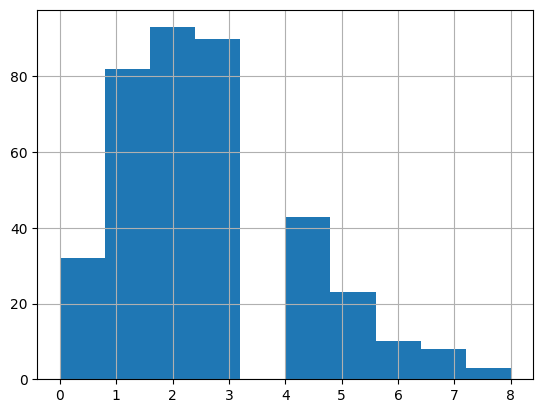

<Figure size 640x480 with 0 Axes>

In [12]:
men_subset["goals_scored"].hist()
plt.show()
plt.clf()

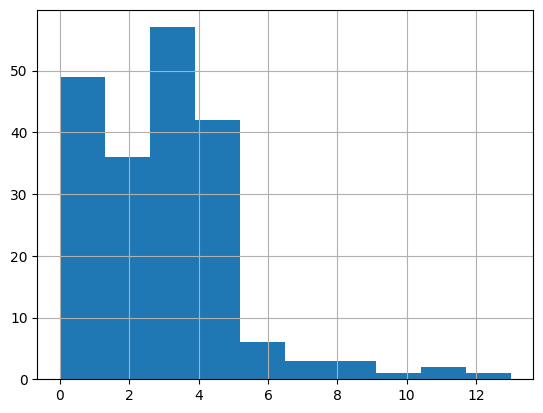

<Figure size 640x480 with 0 Axes>

In [13]:
women_subset["goals_scored"].hist()
plt.show()
plt.clf()

In [14]:
results_scipy = mannwhitneyu(x=women_subset["goals_scored"],
                             y=men_subset["goals_scored"],
                             alternative="greater")

In [15]:
print(results_scipy)

MannwhitneyuResult(statistic=43273.0, pvalue=0.005106609825443641)


In [16]:
p_val = results_scipy[1]

In [17]:
if p_val <= 0.01:
    result = "reject"
else:
    result = "fail to reject"

result_dict = {"p_val": p_val, "result": result}

In [18]:
print(result_dict)

{'p_val': 0.005106609825443641, 'result': 'reject'}
